In [1]:
pip install openai python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

print(os.getcwd())

/Users/yurujia/Desktop/Dissertation Data/sentiment


In [3]:
import os

print(os.listdir())

['USA_sentiment.ipynb', '.env', 'China_sentiment.ipynb']


In [4]:
from dotenv import load_dotenv
from openai import OpenAI
import os

load_dotenv(
    "/Users/yurujia/Desktop/Dissertation Data/sentiment/.env"
)

key = os.getenv("OPENAI_API_KEY")

if key:
    print("API key loaded successfully")
else:
    print("API key NOT found")

client = OpenAI()

MODEL = "gpt-5-mini"

API key loaded successfully


In [5]:
# %%
# ============================================================
# 1. Test API connection
# ============================================================

test_text = """
Waymo announced an expansion of its autonomous ride-hailing
service into additional areas of the city.
"""

response = client.responses.create(
    model=MODEL,
    input=f"""
Classify the sentiment of the following news text toward autonomous vehicles.

Use exactly one label:

1 = Positive
0 = Neutral
-1 = Negative

Return only the numerical label.

News text:
{test_text}
"""
)

print(response.output_text)

1


In [6]:
# %%
# ============================================================
# 2. Load English validation samples
# ============================================================

import pandas as pd
from pathlib import Path

BASE_DIR = Path(
    "/Users/yurujia/Desktop/Dissertation Data/USA"
)

USA_PATH = BASE_DIR / "descriptive_stats_USA_Today/USA_Today_topic_multilabel_annotated_av_relevant_paragraph.xlsx"
WSJ_PATH = BASE_DIR / "descriptive_stats_WSJ/WSJ_topic_multilabel_annotated.xlsx"

usa = pd.read_excel(USA_PATH)
wsj = pd.read_excel(WSJ_PATH)

print("USA Today shape:", usa.shape)
print("WSJ shape:", wsj.shape)

print("\nUSA Today columns:")
print(usa.columns.tolist())

print("\nWSJ columns:")
print(wsj.columns.tolist())

USA Today shape: (29, 121)
WSJ shape: (37, 89)

USA Today columns:
['prompt_validation_id', 'news_source', 'prompt_text_column', 'prompt_input_text', 'file', 'title', 'source', 'date', 'content', '_original_order', 'date_original', 'date_parsed_direct', 'date_fixed', 'article_body', 'full_text_extracted', 'content_char_length', 'full_text_word_count', 'exclude_invalid_date', 'exclude_missing_article_body', 'exclude_initial_unusable_record', 'initial_exclusion_reason', 'automated_screen_text', 'has_general_road_av_term', 'has_higher_automation_term', 'has_passenger_robotaxi_term', 'has_strong_passenger_robotaxi_term', 'has_bus_public_transport_term', 'has_adas_term', 'has_road_vehicle_context', 'has_strong_non_road_term', 'has_general_non_road_context', 'has_av_company_term', 'has_non_road_term', 'has_explicit_av_signal', 'has_company_supported_av_signal', 'has_broad_road_av_relevance', 'remove_no_relevant_road_av_term', 'remove_pure_non_road', 'remove_bus_public_transport_only', 'revie

In [7]:
# %%
# ============================================================
# 3. Standardise English validation dataset
# ============================================================

usa_validation = pd.DataFrame({
    "source": "USA Today",
    "text": usa["av_relevant_paragraph"],
    "human_sentiment": usa["human_sentiment_label"]
})

wsj_validation = pd.DataFrame({
    "source": "WSJ",
    "text": wsj["abstract"],
    "human_sentiment": wsj["human_sentiment_label"]
})

english_validation = pd.concat(
    [usa_validation, wsj_validation],
    ignore_index=True
)

print("Combined English validation shape:")
print(english_validation.shape)

display(english_validation.head())

Combined English validation shape:
(66, 3)


,source,text,human_sentiment
0,USA Today,"Not that long ago, checking in on the state of...",0
1,USA Today,Fiat Chrysler's decision to launch an ultra-po...,0
2,USA Today,A self-driving car flipped on its side seems g...,-1
3,USA Today,So if you're skeptical or nervous about the co...,1
4,USA Today,General Motors said Tuesday it has finished ma...,1


In [8]:
# %%
# ============================================================
# 4. Sentiment prompts
# ============================================================

def build_prompt_p1(text):
    return f"""
You are performing sentiment classification for an academic research project on news coverage of autonomous vehicles.

Classify the sentiment of the following news text toward autonomous vehicles, autonomous driving technology, or their development and deployment.

Use exactly one of the following labels:

1 = Positive
0 = Neutral
-1 = Negative

Return only the numerical label: 1, 0, or -1.

News text:
{text}
"""

In [9]:
def build_prompt_p2(text):
    return f"""
You are performing sentiment classification for an academic research project on news coverage of autonomous vehicles.

Your task is to classify the sentiment expressed toward autonomous vehicles, autonomous driving technology, or their development and deployment.

Use the following definitions:

1 = Positive
The text presents autonomous vehicles or autonomous driving in a predominantly favorable way. This may include technological progress, innovation, benefits, improved safety, successful testing or deployment, commercial expansion, supportive developments, or promising future prospects.

0 = Neutral
The text is predominantly factual, descriptive, balanced, or mixed and does not clearly evaluate autonomous vehicles positively or negatively.

-1 = Negative
The text presents autonomous vehicles or autonomous driving in a predominantly unfavorable way. This may include technological failure, safety risks, crashes, unreliability, criticism, legal or regulatory problems, public concern, setbacks, or limitations.

Classify sentiment specifically toward autonomous vehicles or autonomous driving rather than the general emotional tone of the news story.

Return only the numerical label: 1, 0, or -1.

News text:
{text}
"""

In [10]:
def build_prompt_p3(text):
    return f"""
You are performing sentiment classification for an academic research project on news coverage of autonomous vehicles.

Your task is to determine the overall evaluative orientation of the text toward autonomous vehicles, autonomous driving technology, or their development and deployment.

Use the following labels:

1 = Positive
The text predominantly presents autonomous vehicles or autonomous driving favorably, including technological progress, innovation, benefits, improved safety, successful testing or deployment, commercial expansion, supportive policy developments, or optimistic expectations.

0 = Neutral
The text is predominantly factual, descriptive, balanced, or mixed, without a clearly dominant positive or negative evaluation of autonomous vehicles.

-1 = Negative
The text predominantly presents autonomous vehicles or autonomous driving unfavorably, including technological failures, safety risks, crashes attributed to autonomous driving, unreliability, criticism, regulatory or legal obstacles, public concern, setbacks, or limitations.

Apply the following decision rules:

1. Evaluate sentiment specifically toward autonomous vehicles or autonomous driving, not the general emotional tone of the story.

2. Do not classify a text as negative solely because it mentions a crash, injury, death, investigation, lawsuit, or regulation. Classify it as negative only when these elements contribute to an unfavorable evaluation or framing of autonomous driving.

3. Do not classify a text as positive solely because it mentions technological development, investment, testing, a launch, or a company announcement. There must be a clearly favorable framing or implication.

4. Purely factual reporting of an event, policy announcement, business transaction, test, launch, expansion, or regulatory development should normally be classified as neutral unless the text clearly frames the development positively or negatively.

5. When both positive and negative information is present, identify the dominant evaluative direction. If neither clearly dominates, classify the text as neutral.

6. Sentiment toward a company, executive, stock price, financial performance, or broader business conditions should not determine the label unless it directly reflects an evaluation of autonomous driving technology or deployment.

7. Sentiment expressed in quotations should be considered only insofar as the quotation contributes to the overall framing of autonomous vehicles in the supplied text.

8. Base the decision only on the supplied text. Do not use outside knowledge.

Return only the numerical label: 1, 0, or -1.

News text:
{text}
"""

In [11]:
# %%
# ============================================================
# 5. API classification function
# ============================================================

import time

def classify_sentiment(prompt, max_retries=3):
    for attempt in range(max_retries):
        try:
            response = client.responses.create(
                model=MODEL,
                input=prompt
            )

            result = response.output_text.strip()

            if result in {"1", "0", "-1"}:
                return int(result)

            print(f"Unexpected output: {result}")
            return None

        except Exception as e:
            print(f"API error on attempt {attempt + 1}: {e}")

            if attempt < max_retries - 1:
                time.sleep(2)
            else:
                return None

In [12]:
# %%
# ============================================================
# 6. Small test on first 5 rows
# ============================================================

test_df = english_validation.head(5).copy()

for idx, row in test_df.iterrows():

    text = row["text"]

    p1_result = classify_sentiment(
        build_prompt_p1(text)
    )

    p2_result = classify_sentiment(
        build_prompt_p2(text)
    )

    p3_result = classify_sentiment(
        build_prompt_p3(text)
    )

    print("=" * 80)
    print("Source:", row["source"])
    print("Human:", row["human_sentiment"])
    print("P1:", p1_result)
    print("P2:", p2_result)
    print("P3:", p3_result)

Source: USA Today
Human: 0
P1: 0
P2: 0
P3: 0
Source: USA Today
Human: 0
P1: 0
P2: 0
P3: 0
Source: USA Today
Human: -1
P1: -1
P2: -1
P3: -1
Source: USA Today
Human: 1
P1: 1
P2: 1
P3: 1
Source: USA Today
Human: 1
P1: 1
P2: 1
P3: 1


In [13]:
# %%
# ============================================================
# 7. Run P1 / P2 / P3 on full English validation sample
# ============================================================

results = english_validation.copy()

results["P1_EN"] = None
results["P2_EN"] = None
results["P3_EN"] = None


for idx, row in results.iterrows():

    text = row["text"]

    print(
        f"Processing {idx + 1}/{len(results)} "
        f"| {row['source']}"
    )

    results.at[idx, "P1_EN"] = classify_sentiment(
        build_prompt_p1(text)
    )

    results.at[idx, "P2_EN"] = classify_sentiment(
        build_prompt_p2(text)
    )

    results.at[idx, "P3_EN"] = classify_sentiment(
        build_prompt_p3(text)
    )

Processing 1/66 | USA Today
Processing 2/66 | USA Today
Processing 3/66 | USA Today
Processing 4/66 | USA Today
Processing 5/66 | USA Today
Processing 6/66 | USA Today
Processing 7/66 | USA Today
Processing 8/66 | USA Today
Processing 9/66 | USA Today
Processing 10/66 | USA Today
Processing 11/66 | USA Today
Processing 12/66 | USA Today
Processing 13/66 | USA Today
Processing 14/66 | USA Today
Processing 15/66 | USA Today
Processing 16/66 | USA Today
Processing 17/66 | USA Today
Processing 18/66 | USA Today
Processing 19/66 | USA Today
Processing 20/66 | USA Today
Processing 21/66 | USA Today
Processing 22/66 | USA Today
Processing 23/66 | USA Today
Processing 24/66 | USA Today
Processing 25/66 | USA Today
Processing 26/66 | USA Today
Processing 27/66 | USA Today
Processing 28/66 | USA Today
Processing 29/66 | USA Today
Processing 30/66 | WSJ
Processing 31/66 | WSJ
Processing 32/66 | WSJ
Processing 33/66 | WSJ
Processing 34/66 | WSJ
Processing 35/66 | WSJ
Processing 36/66 | WSJ
Process

In [14]:
# %%
# ============================================================
# 8. Save raw prompt outputs
# ============================================================

OUTPUT_PATH = (
    BASE_DIR /
    "english_sentiment_prompt_validation_results.xlsx"
)

results.to_excel(
    OUTPUT_PATH,
    index=False
)

print("Saved to:")
print(OUTPUT_PATH)

Saved to:
/Users/yurujia/Desktop/Dissertation Data/USA/english_sentiment_prompt_validation_results.xlsx


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [27]:
# %%
# ============================================================
# 9. Evaluate prompts
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

prompt_columns = [
    "P1_EN",
    "P2_EN",
    "P3_EN"
]

evaluation_rows = []

for prompt_col in prompt_columns:

    valid = results[
        results[prompt_col].notna()
    ].copy()

    y_true = valid["human_sentiment"].astype(int)
    y_pred = valid[prompt_col].astype(int)

    evaluation_rows.append({
        "prompt": prompt_col,
        "n": len(valid),
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "macro_precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "macro_recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "cohen_kappa": cohen_kappa_score(
            y_true,
            y_pred
        )
    })

evaluation_df = pd.DataFrame(
    evaluation_rows
)

display(evaluation_df)

,prompt,n,accuracy,macro_precision,macro_recall,macro_f1,cohen_kappa
0,P1_EN,66,0.696970,0.780811,0.714566,0.685657,0.538300
1,P2_EN,66,0.727273,0.790451,0.753782,0.725750,0.583596
2,P3_EN,66,0.666667,0.781481,0.750140,0.693202,0.518408


In [17]:
# %%
# ============================================================
# 10. Evaluate by source
# ============================================================

source_evaluation_rows = []

for source_name in results["source"].unique():

    source_df = results[
        results["source"] == source_name
    ]

    for prompt_col in prompt_columns:

        valid = source_df[
            source_df[prompt_col].notna()
        ].copy()

        y_true = valid["human_sentiment"].astype(int)
        y_pred = valid[prompt_col].astype(int)

        source_evaluation_rows.append({
            "source": source_name,
            "prompt": prompt_col,
            "n": len(valid),
            "accuracy": accuracy_score(
                y_true,
                y_pred
            ),
            "macro_f1": f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            )
        })

source_evaluation_df = pd.DataFrame(
    source_evaluation_rows
)

display(source_evaluation_df)

,source,prompt,n,accuracy,macro_f1
0,USA Today,P1_EN,29,0.689655,0.709557
1,USA Today,P2_EN,29,0.758621,0.761905
2,USA Today,P3_EN,29,0.689655,0.711111
3,WSJ,P1_EN,37,0.702703,0.667961
4,WSJ,P2_EN,37,0.702703,0.695799
5,WSJ,P3_EN,37,0.648649,0.666897


In [18]:
# %%
# ============================================================
# 11. Class-level performance by source and prompt
# ============================================================

from sklearn.metrics import classification_report
import pandas as pd

for source_name in results["source"].unique():

    print("\n" + "=" * 100)
    print(f"SOURCE: {source_name}")
    print("=" * 100)

    source_df = results[
        results["source"] == source_name
    ].copy()

    for prompt_col in prompt_columns:

        valid = source_df[
            source_df[prompt_col].notna()
        ].copy()

        y_true = valid["human_sentiment"].astype(int)
        y_pred = valid[prompt_col].astype(int)

        print("\n" + "-" * 80)
        print(f"PROMPT: {prompt_col}")
        print("-" * 80)

        report = classification_report(
            y_true,
            y_pred,
            labels=[-1, 0, 1],
            target_names=[
                "Negative",
                "Neutral",
                "Positive"
            ],
            output_dict=True,
            zero_division=0
        )

        report_df = pd.DataFrame(report).T

        display(
            report_df[
                ["precision", "recall", "f1-score", "support"]
            ]
        )


SOURCE: USA Today

--------------------------------------------------------------------------------
PROMPT: P1_EN
--------------------------------------------------------------------------------


,precision,recall,f1-score,support
Negative,1.000000,0.666667,0.800000,6.000000
Neutral,0.500000,0.875000,0.636364,8.000000
Positive,0.818182,0.600000,0.692308,15.000000
accuracy,0.689655,0.689655,0.689655,0.689655
macro avg,0.772727,0.713889,0.709557,29.000000
weighted avg,0.768025,0.689655,0.699156,29.000000



--------------------------------------------------------------------------------
PROMPT: P2_EN
--------------------------------------------------------------------------------


,precision,recall,f1-score,support
Negative,1.000000,0.666667,0.800000,6.000000
Neutral,0.583333,0.875000,0.700000,8.000000
Positive,0.846154,0.733333,0.785714,15.000000
accuracy,0.758621,0.758621,0.758621,0.758621
macro avg,0.809829,0.758333,0.761905,29.000000
weighted avg,0.805482,0.758621,0.765025,29.000000



--------------------------------------------------------------------------------
PROMPT: P3_EN
--------------------------------------------------------------------------------


...

,precision,recall,f1-score,support
Negative,1.000000,0.454545,0.625000,11.000000
Neutral,0.352941,1.000000,0.521739,6.000000
Positive,1.000000,0.750000,0.857143,20.000000
accuracy,0.702703,0.702703,0.702703,0.702703
macro avg,0.784314,0.734848,0.667961,37.000000
weighted avg,0.895072,0.702703,0.733738,37.000000



--------------------------------------------------------------------------------
PROMPT: P2_EN
--------------------------------------------------------------------------------


,precision,recall,f1-score,support
Negative,1.000000,0.636364,0.777778,11.000000
Neutral,0.352941,1.000000,0.521739,6.000000
Positive,1.000000,0.650000,0.787879,20.000000
accuracy,0.702703,0.702703,0.702703,0.702703
macro avg,0.784314,0.762121,0.695799,37.000000
weighted avg,0.895072,0.702703,0.741718,37.000000



--------------------------------------------------------------------------------
PROMPT: P3_EN
--------------------------------------------------------------------------------


,precision,recall,f1-score,support
Negative,1.000000,0.818182,0.900000,11.000000
Neutral,0.315789,1.000000,0.480000,6.000000
Positive,1.000000,0.450000,0.620690,20.000000
accuracy,0.648649,0.648649,0.648649,0.648649
macro avg,0.771930,0.756061,0.666897,37.000000
weighted avg,0.889047,0.648649,0.680913,37.000000


In [19]:
# %%
# ============================================================
# 12. Compare label distributions
# ============================================================

for source_name in results["source"].unique():

    print("\n" + "=" * 80)
    print(f"SOURCE: {source_name}")
    print("=" * 80)

    source_df = results[
        results["source"] == source_name
    ].copy()

    columns_to_check = [
        "human_sentiment",
        "P1_EN",
        "P2_EN",
        "P3_EN"
    ]

    distribution = {}

    for col in columns_to_check:

        counts = (
            source_df[col]
            .dropna()
            .astype(int)
            .value_counts()
            .reindex([-1, 0, 1], fill_value=0)
        )

        distribution[col] = counts

    distribution_df = pd.DataFrame(distribution)

    distribution_df.index = [
        "Negative (-1)",
        "Neutral (0)",
        "Positive (1)"
    ]

    display(distribution_df)


SOURCE: USA Today


,human_sentiment,P1_EN,P2_EN,P3_EN
Negative (-1),6,4,4,4
Neutral (0),8,14,12,16
Positive (1),15,11,13,9



SOURCE: WSJ


,human_sentiment,P1_EN,P2_EN,P3_EN
Negative (-1),11,5,7,9
Neutral (0),6,17,17,19
Positive (1),20,15,13,9




P1_EN


,Negative,Neutral,Positive
Negative,9,7,1
Neutral,0,13,1
Positive,0,11,24


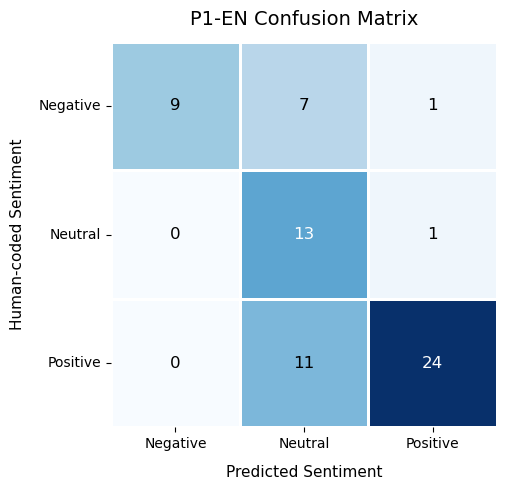



P2_EN


,Negative,Neutral,Positive
Negative,11,5,1
Neutral,0,13,1
Positive,0,11,24


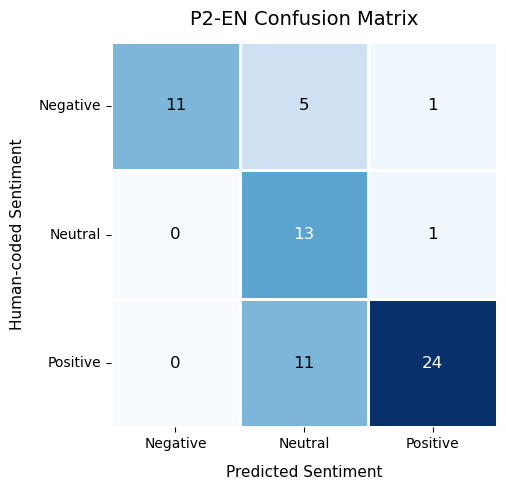



P3_EN


,Negative,Neutral,Positive
Negative,13,3,1
Neutral,0,14,0
Positive,0,18,17


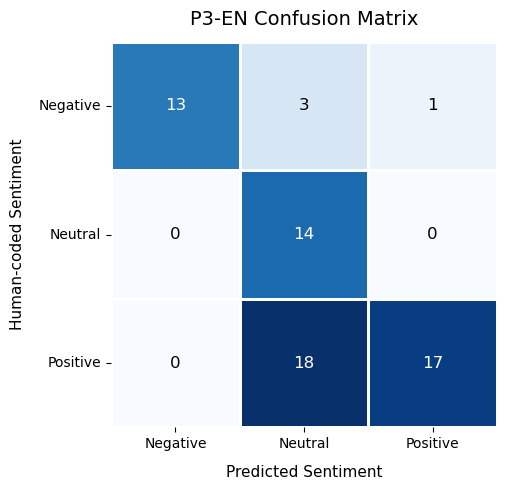



P2R_EN


,Negative,Neutral,Positive
Negative,13,3,1
Neutral,2,8,4
Positive,0,1,34


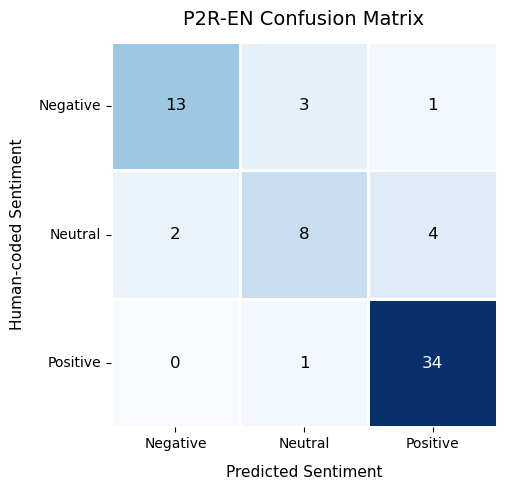



P1_EN
Number of errors: 20
error_type
Positive → Neutral     11
Negative → Neutral      7
Negative → Positive     1
Neutral → Positive      1
Name: count, dtype: int64


P2_EN
Number of errors: 18
error_type
Positive → Neutral     11
Negative → Neutral      5
Negative → Positive     1
Neutral → Positive      1
Name: count, dtype: int64


P3_EN
Number of errors: 22
error_type
Positive → Neutral     18
Negative → Neutral      3
Negative → Positive     1
Name: count, dtype: int64


P2R_EN
Number of errors: 11
error_type
Neutral → Positive     4
Negative → Neutral     3
Neutral → Negative     2
Negative → Positive    1
Positive → Neutral     1
Name: count, dtype: int64


,prompt,error_type,count
0,P1_EN,Positive → Neutral,11
1,P1_EN,Negative → Neutral,7
2,P1_EN,Negative → Positive,1
3,P1_EN,Neutral → Positive,1
4,P2_EN,Positive → Neutral,11
5,P2_EN,Negative → Neutral,5
6,P2_EN,Negative → Positive,1
7,P2_EN,Neutral → Positive,1
8,P3_EN,Positive → Neutral,18
9,P3_EN,Negative → Neutral,3


In [28]:
# %%
# ============================================================
# 13. Sentiment Error Analysis
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix


# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

ERROR_OUTPUT_DIR = BASE_DIR / "sentiment_error_analysis"

ERROR_OUTPUT_DIR.mkdir(
    exist_ok=True
)


# ------------------------------------------------------------
# Prompt columns
# ------------------------------------------------------------

prompt_columns = [
    "P1_EN",
    "P2_EN",
    "P3_EN",
    "P2R_EN"
]


# ------------------------------------------------------------
# Sentiment label mapping
# ------------------------------------------------------------

label_map = {
    -1: "Negative",
     0: "Neutral",
     1: "Positive"
}


# %%
# ============================================================
# 13.1 Confusion Matrix for Each Prompt
# ============================================================

for prompt_col in prompt_columns:

    print("\n")
    print("=" * 80)
    print(prompt_col)
    print("=" * 80)

    # Keep observations with valid model predictions
    valid = results[
        results[prompt_col].notna()
    ].copy()

    # Human-coded labels
    y_true = (
        valid["human_sentiment"]
        .astype(int)
    )

    # Model-predicted labels
    y_pred = (
        valid[prompt_col]
        .astype(int)
    )

    # Generate confusion matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[-1, 0, 1]
    )

    # Convert to DataFrame
    cm_df = pd.DataFrame(
        cm,
        index=[
            "Negative",
            "Neutral",
            "Positive"
        ],
        columns=[
            "Negative",
            "Neutral",
            "Positive"
        ]
    )

    # Display table
    display(cm_df)

    # Save confusion matrix table
    cm_df.to_excel(
        ERROR_OUTPUT_DIR /
        f"{prompt_col}_confusion_matrix.xlsx"
    )

    # --------------------------------------------------------
    # Plot confusion matrix
    # --------------------------------------------------------

    plt.figure(
        figsize=(6, 5)
    )

    ax = sns.heatmap(
        cm_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        linewidths=1,
        linecolor="white",
        annot_kws={
            "fontsize": 12
        }
    )

    # Make annotation colour readable
    threshold = cm.max() / 2

    for text, value in zip(
        ax.texts,
        cm.flatten()
    ):
        if value > threshold:
            text.set_color("white")
        else:
            text.set_color("black")

    # Title
    plt.title(
        f"{prompt_col.replace('_', '-')} Confusion Matrix",
        fontsize=14,
        pad=12
    )

    # Axis labels
    plt.xlabel(
        "Predicted Sentiment",
        fontsize=11,
        labelpad=10
    )

    plt.ylabel(
        "Human-coded Sentiment",
        fontsize=11,
        labelpad=10
    )

    # Tick labels
    plt.xticks(
        rotation=0,
        fontsize=10
    )

    plt.yticks(
        rotation=0,
        fontsize=10
    )

    plt.tight_layout()

    # Save figure
    plt.savefig(
        ERROR_OUTPUT_DIR /
        f"{prompt_col}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# %%
# ============================================================
# 13.2 Misclassification Pattern Analysis
# ============================================================

all_error_patterns = []

for prompt_col in prompt_columns:

    print("\n")
    print("=" * 80)
    print(prompt_col)
    print("=" * 80)

    # Keep valid predictions
    valid = results[
        results[prompt_col].notna()
    ].copy()

    # Identify misclassified observations
    errors = valid[
        valid["human_sentiment"]
        !=
        valid[prompt_col]
    ].copy()

    # Convert human labels to text
    errors["human_label_text"] = (
        errors["human_sentiment"]
        .map(label_map)
    )

    # Convert predicted labels to text
    errors["prediction_label_text"] = (
        errors[prompt_col]
        .map(label_map)
    )

    # Create error type
    errors["error_type"] = (
        errors["human_label_text"]
        +
        " → "
        +
        errors["prediction_label_text"]
    )

    # Print number of errors
    print(
        "Number of errors:",
        len(errors)
    )

    # Print error distribution
    print(
        errors["error_type"]
        .value_counts()
    )

    # Save individual misclassified observations
    errors.to_excel(
        ERROR_OUTPUT_DIR /
        f"{prompt_col}_misclassified_examples.xlsx",
        index=False
    )

    # Summarise error patterns
    pattern = (
        errors["error_type"]
        .value_counts()
        .reset_index()
    )

    pattern.columns = [
        "error_type",
        "count"
    ]

    pattern["prompt"] = prompt_col

    all_error_patterns.append(
        pattern
    )


# %%
# ============================================================
# 13.3 Combine Error Patterns
# ============================================================

error_pattern_df = pd.concat(
    all_error_patterns,
    ignore_index=True
)

# Reorder columns
error_pattern_df = error_pattern_df[
    [
        "prompt",
        "error_type",
        "count"
    ]
]

display(
    error_pattern_df
)

# Save combined error pattern table
error_pattern_df.to_excel(
    ERROR_OUTPUT_DIR /
    "sentiment_error_patterns.xlsx",
    index=False
)

In [20]:
def build_prompt_p2r(text):
    return f"""
You are performing sentiment classification for an academic research project on news coverage of autonomous vehicles.

Your task is to classify the overall evaluative orientation of the following news text toward autonomous vehicles, autonomous driving technology, or their development and deployment.

Use the following labels:

1 = Positive

Classify the text as positive when it predominantly presents autonomous vehicles or autonomous driving in a favorable direction.

Positive sentiment may be expressed explicitly or implicitly. Explicit positive words are not required.

Indicators may include:
- technological progress or successful development;
- successful testing, deployment, commercialization, or expansion;
- demonstrated improvements in safety or performance;
- benefits for users, society, mobility, or industry;
- supportive developments that facilitate autonomous driving;
- optimistic expectations about future development.

A factual description of successful progress or beneficial development may therefore still be classified as positive when its overall implication toward autonomous driving is clearly favorable.


0 = Neutral

Classify the text as neutral when it primarily provides information about autonomous vehicles without a discernible positive or negative evaluative direction.

Neutral should be used when:
- the text mainly reports facts without implying clear progress, benefit, risk, failure, or setback;
- positive and negative elements are both present and neither clearly dominates; or
- autonomous driving is mentioned only as contextual information rather than being meaningfully evaluated.

Do not classify a text as neutral merely because it is written in an objective or factual news style. News reporting can convey positive or negative framing through the developments and consequences it emphasizes.


-1 = Negative

Classify the text as negative when it predominantly presents autonomous vehicles or autonomous driving in an unfavorable direction.

Negative sentiment may be expressed explicitly or implicitly. Explicit negative words are not required.

Indicators may include:
- technological failure or poor performance;
- safety problems or risks associated with autonomous driving;
- crashes or harmful outcomes linked to autonomous-system performance;
- suspension, restriction, cancellation, or setbacks in testing or deployment;
- criticism, public concern, legal problems, or regulatory obstacles;
- evidence suggesting limitations, unreliability, or adverse consequences.

A factual description of a significant failure, safety problem, restriction, or setback may therefore still be classified as negative when its overall implication toward autonomous driving is clearly unfavorable.


Important:

Evaluate sentiment specifically toward autonomous vehicles, autonomous driving technology, or their development and deployment.

Do not base the classification on the general emotional tone of the story, the performance of a company's stock, or unrelated business developments.

When both positive and negative elements appear, classify according to the dominant evaluative direction. Use neutral only when neither direction clearly predominates.

Base the classification only on the supplied text. Do not use outside knowledge.

Return only the numerical label: 1, 0, or -1.

News text:
{text}
"""

In [21]:
# %%
# ============================================================
# 13. Run refined P2-R prompt
# ============================================================

results["P2R_EN"] = None

for idx, row in results.iterrows():

    text = row["text"]

    print(
        f"Processing {idx + 1}/{len(results)} "
        f"| {row['source']}"
    )

    results.at[idx, "P2R_EN"] = classify_sentiment(
        build_prompt_p2r(text)
    )

Processing 1/66 | USA Today
Processing 2/66 | USA Today
Processing 3/66 | USA Today
Processing 4/66 | USA Today
Processing 5/66 | USA Today
Processing 6/66 | USA Today
Processing 7/66 | USA Today
Processing 8/66 | USA Today
Processing 9/66 | USA Today
Processing 10/66 | USA Today
Processing 11/66 | USA Today
Processing 12/66 | USA Today
Processing 13/66 | USA Today
Processing 14/66 | USA Today
Processing 15/66 | USA Today
Processing 16/66 | USA Today
Processing 17/66 | USA Today
Processing 18/66 | USA Today
Processing 19/66 | USA Today
Processing 20/66 | USA Today
Processing 21/66 | USA Today
Processing 22/66 | USA Today
Processing 23/66 | USA Today
Processing 24/66 | USA Today
Processing 25/66 | USA Today
Processing 26/66 | USA Today
Processing 27/66 | USA Today
Processing 28/66 | USA Today
Processing 29/66 | USA Today
Processing 30/66 | WSJ
Processing 31/66 | WSJ
Processing 32/66 | WSJ
Processing 33/66 | WSJ
Processing 34/66 | WSJ
Processing 35/66 | WSJ
Processing 36/66 | WSJ
Process

In [22]:
OUTPUT_PATH_REFINED = (
    BASE_DIR /
    "english_sentiment_prompt_validation_results_refined.xlsx"
)

results.to_excel(
    OUTPUT_PATH_REFINED,
    index=False
)

print("Saved to:")
print(OUTPUT_PATH_REFINED)

Saved to:
/Users/yurujia/Desktop/Dissertation Data/USA/english_sentiment_prompt_validation_results_refined.xlsx


In [23]:
# %%
# ============================================================
# 14. Compare P1 / P2 / P3 / P2-R
# ============================================================

prompt_columns_refined = [
    "P1_EN",
    "P2_EN",
    "P3_EN",
    "P2R_EN"
]

evaluation_rows = []

for prompt_col in prompt_columns_refined:

    valid = results[
        results[prompt_col].notna()
    ].copy()

    y_true = valid["human_sentiment"].astype(int)
    y_pred = valid[prompt_col].astype(int)

    evaluation_rows.append({
        "prompt": prompt_col,
        "n": len(valid),

        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "macro_precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "macro_recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    })

evaluation_refined_df = pd.DataFrame(
    evaluation_rows
)

display(evaluation_refined_df)

,prompt,n,accuracy,macro_precision,macro_recall,macro_f1
0,P1_EN,66,0.696970,0.780811,0.714566,0.685657
1,P2_EN,66,0.727273,0.790451,0.753782,0.725750
2,P3_EN,66,0.666667,0.781481,0.750140,0.693202
3,P2R_EN,66,0.833333,0.801709,0.769188,0.782268


In [24]:
# %%
# ============================================================
# 15. Compare P2-R label distribution with human coding
# ============================================================

for source_name in results["source"].unique():

    print("\n" + "=" * 80)
    print(f"SOURCE: {source_name}")
    print("=" * 80)

    source_df = results[
        results["source"] == source_name
    ].copy()

    columns_to_check = [
        "human_sentiment",
        "P1_EN",
        "P2_EN",
        "P3_EN",
        "P2R_EN"
    ]

    distribution = {}

    for col in columns_to_check:

        counts = (
            source_df[col]
            .dropna()
            .astype(int)
            .value_counts()
            .reindex([-1, 0, 1], fill_value=0)
        )

        distribution[col] = counts

    distribution_df = pd.DataFrame(distribution)

    distribution_df.index = [
        "Negative (-1)",
        "Neutral (0)",
        "Positive (1)"
    ]

    display(distribution_df)


SOURCE: USA Today


,human_sentiment,P1_EN,P2_EN,P3_EN,P2R_EN
Negative (-1),6,4,4,4,5
Neutral (0),8,14,12,16,7
Positive (1),15,11,13,9,17



SOURCE: WSJ


,human_sentiment,P1_EN,P2_EN,P3_EN,P2R_EN
Negative (-1),11,5,7,9,10
Neutral (0),6,17,17,19,5
Positive (1),20,15,13,9,22


In [25]:
# %%
# ============================================================
# 16. P2R2-EN: Lightly Refined P2 Prompt
# ============================================================

def build_prompt_p2r2(text):
    return f"""
You are performing sentiment classification for an academic research project on news coverage of autonomous vehicles.

Your task is to classify the overall evaluative orientation of the following news text toward autonomous vehicles, autonomous driving technology, or their development and deployment.

Use the following labels:

1 = Positive

Classify the text as positive when it predominantly presents autonomous vehicles or autonomous driving in a favorable direction.

Positive sentiment may be expressed explicitly or implicitly. Explicit positive words are not required.

Indicators may include:
- technological progress or successful development;
- successful testing, deployment, commercialization, or expansion;
- demonstrated improvements in safety, efficiency, performance, or reliability;
- benefits for users, society, mobility, or industry;
- supportive policy, infrastructure, or regulatory developments;
- meaningful progress in the development or deployment of autonomous driving;
- optimistic expectations about future development.

Important:

Objective or factual news reporting can still be classified as Positive.

If the reported development itself clearly represents meaningful technological progress, successful implementation, expanded deployment, demonstrated benefit, or another favorable outcome for autonomous driving, the text may be classified as Positive even without explicit evaluative language.


0 = Neutral

Classify the text as neutral when it primarily provides information about autonomous vehicles without a clearly dominant positive or negative evaluative direction.

Neutral may include:
- background information or technical description;
- announcements of future research, planned testing, intended cooperation, or proposed deployment without evidence of an actual outcome;
- descriptions of a test, project, business action, policy discussion, or company announcement whose implications for autonomous driving are unclear;
- cases where autonomous driving is mentioned mainly as context;
- mixed positive and negative elements where neither direction clearly dominates.

Important:

Do not classify a text as Positive solely because it mentions development, testing, investment, cooperation, deployment, expansion, licensing, or a company announcement.

However, do not classify such reporting as Neutral merely because it is factual or objective.

Distinguish between:

- the existence of an activity, plan, announcement, or test; and
- evidence that the activity produced meaningful progress, successful results, improved capability, expanded deployment, or another favorable outcome.

If the text reports only the former, Neutral is more appropriate.

If the text clearly reports the latter, Positive is more appropriate.


-1 = Negative

Classify the text as negative when it predominantly presents autonomous vehicles or autonomous driving in an unfavorable direction.

Negative sentiment may be expressed explicitly or implicitly. Explicit negative words are not required.

Indicators may include:
- technological failure or poor performance;
- safety problems or risks associated with autonomous driving;
- crashes or harmful outcomes linked to autonomous-system performance;
- suspension, restriction, cancellation, or setbacks in testing or deployment;
- criticism, public concern, legal problems, or regulatory obstacles;
- evidence suggesting limitations, unreliability, or adverse consequences.

Objective or factual news reporting can still be classified as Negative when the reported development itself clearly represents failure, restriction, harm, or a setback for autonomous driving.


Important decision rules:

1. Evaluate sentiment specifically toward autonomous vehicles, autonomous driving technology, or their development and deployment.

2. Do not base the classification on the general emotional tone of the story, a company's stock performance, financial results, executives, or unrelated business developments.

3. Objective news style does not automatically mean Neutral. Evaluate the implications of the reported development.

4. Distinguish between the existence of an activity and evidence of a meaningful outcome.

For example:
- announcing a future test, research plan, partnership, or intended deployment may be Neutral;
- successfully completing a test, expanding an operating service, demonstrating improved performance, or achieving a meaningful deployment milestone may be Positive.

5. Positive sentiment does not require explicit praise. The reported facts themselves may imply a favorable or unfavorable orientation.

6. When both positive and negative elements are present, classify according to the dominant evaluative direction. Use Neutral only when neither direction clearly predominates.

7. Base the classification only on the supplied text. Do not use outside knowledge.

Return only the numerical label: 1, 0, or -1.

News text:
{text}
""".strip()

# %%
# ============================================================
# 17. Run P2R2-EN
# ============================================================

results["P2R2_EN"] = None

for idx, row in results.iterrows():

    text = row["text"]

    print(
        f"Processing P2R2-EN: "
        f"{idx + 1}/{len(results)} "
        f"| {row['source']}"
    )

    results.at[idx, "P2R2_EN"] = classify_sentiment(
        build_prompt_p2r2(text)
    )

print("\nP2R2-EN classification completed.")

# %%
# ============================================================
# 18. Check missing P2R2-EN predictions
# ============================================================

print("Missing P2R2-EN predictions:")

print(
    results["P2R2_EN"].isna().sum()
)

missing_p2r2_en = results[
    results["P2R2_EN"].isna()
].copy()

if len(missing_p2r2_en) > 0:

    display(
        missing_p2r2_en[
            [
                "source",
                "text",
                "human_sentiment"
            ]
        ]
    )

else:

    print("No missing predictions.")

# %%
# ============================================================
# 19. Overall evaluation including P2R2-EN
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score
)

prompt_columns_final = [
    "P1_EN",
    "P2_EN",
    "P3_EN",
    "P2R_EN",
    "P2R2_EN"
]

evaluation_rows_final = []

for prompt_col in prompt_columns_final:

    valid = results[
        results[prompt_col].notna()
    ].copy()

    y_true = (
        valid["human_sentiment"]
        .astype(int)
    )

    y_pred = (
        valid[prompt_col]
        .astype(int)
    )

    evaluation_rows_final.append({

        "prompt": prompt_col,

        "n": len(valid),

        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "macro_precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "macro_recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "cohen_kappa": cohen_kappa_score(
            y_true,
            y_pred
        )
    })


evaluation_final_df = pd.DataFrame(
    evaluation_rows_final
)

print("\nFinal overall prompt comparison:")

display(
    evaluation_final_df.round(4)
)

# %%
# ============================================================
# 20. Evaluate all prompts by source
# ============================================================

source_evaluation_rows_final = []

for source_name in results["source"].unique():

    source_df = results[
        results["source"] == source_name
    ].copy()

    for prompt_col in prompt_columns_final:

        valid = source_df[
            source_df[prompt_col].notna()
        ].copy()

        y_true = (
            valid["human_sentiment"]
            .astype(int)
        )

        y_pred = (
            valid[prompt_col]
            .astype(int)
        )

        source_evaluation_rows_final.append({

            "source": source_name,

            "prompt": prompt_col,

            "n": len(valid),

            "accuracy": accuracy_score(
                y_true,
                y_pred
            ),

            "macro_precision": precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

            "macro_recall": recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

            "macro_f1": f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

            "cohen_kappa": cohen_kappa_score(
                y_true,
                y_pred
            )
        })


source_evaluation_final_df = pd.DataFrame(
    source_evaluation_rows_final
)

print("\nPrompt performance by source:")

display(
    source_evaluation_final_df.round(4)
)

# %%
# ============================================================
# 21. P2R2-EN class-level performance overall
# ============================================================

valid_p2r2_en = results[
    results["P2R2_EN"].notna()
].copy()

y_true_p2r2_en = (
    valid_p2r2_en["human_sentiment"]
    .astype(int)
)

y_pred_p2r2_en = (
    valid_p2r2_en["P2R2_EN"]
    .astype(int)
)

print("\n" + "=" * 100)
print("CLASS-LEVEL PERFORMANCE: P2R2_EN")
print("=" * 100)

p2r2_en_report = classification_report(
    y_true_p2r2_en,
    y_pred_p2r2_en,
    labels=[-1, 0, 1],
    target_names=[
        "Negative",
        "Neutral",
        "Positive"
    ],
    output_dict=True,
    zero_division=0
)

p2r2_en_report_df = pd.DataFrame(
    p2r2_en_report
).T

display(
    p2r2_en_report_df[
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ].round(4)
)

# %%
# ============================================================
# 22. P2R2-EN class-level performance by source
# ============================================================

for source_name in results["source"].unique():

    source_df = results[
        (results["source"] == source_name)
        &
        (results["P2R2_EN"].notna())
    ].copy()

    y_true_source = (
        source_df["human_sentiment"]
        .astype(int)
    )

    y_pred_source = (
        source_df["P2R2_EN"]
        .astype(int)
    )

    print("\n" + "=" * 100)
    print(f"P2R2_EN CLASS PERFORMANCE | {source_name}")
    print("=" * 100)

    source_report = classification_report(
        y_true_source,
        y_pred_source,
        labels=[-1, 0, 1],
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ],
        output_dict=True,
        zero_division=0
    )

    source_report_df = pd.DataFrame(
        source_report
    ).T

    display(
        source_report_df[
            [
                "precision",
                "recall",
                "f1-score",
                "support"
            ]
        ].round(4)
    )

# %%
# ============================================================
# 23. P2R2-EN confusion matrix overall
# ============================================================

p2r2_en_cm = confusion_matrix(
    y_true_p2r2_en,
    y_pred_p2r2_en,
    labels=[-1, 0, 1]
)

p2r2_en_cm_df = pd.DataFrame(
    p2r2_en_cm,
    index=[
        "Human Negative",
        "Human Neutral",
        "Human Positive"
    ],
    columns=[
        "Pred Negative",
        "Pred Neutral",
        "Pred Positive"
    ]
)

print("\nP2R2-EN overall confusion matrix:")

display(
    p2r2_en_cm_df
)

# %%
# ============================================================
# 24. P2R2-EN confusion matrix by source
# ============================================================

for source_name in results["source"].unique():

    source_df = results[
        (results["source"] == source_name)
        &
        (results["P2R2_EN"].notna())
    ].copy()

    y_true_source = (
        source_df["human_sentiment"]
        .astype(int)
    )

    y_pred_source = (
        source_df["P2R2_EN"]
        .astype(int)
    )

    source_cm = confusion_matrix(
        y_true_source,
        y_pred_source,
        labels=[-1, 0, 1]
    )

    source_cm_df = pd.DataFrame(
        source_cm,
        index=[
            "Human Negative",
            "Human Neutral",
            "Human Positive"
        ],
        columns=[
            "Pred Negative",
            "Pred Neutral",
            "Pred Positive"
        ]
    )

    print("\n" + "=" * 80)
    print(f"P2R2_EN CONFUSION MATRIX | {source_name}")
    print("=" * 80)

    display(
        source_cm_df
    )

# %%
# ============================================================
# 25. Compare label counts overall
# ============================================================

columns_to_check_final = [
    "human_sentiment",
    "P1_EN",
    "P2_EN",
    "P3_EN",
    "P2R_EN",
    "P2R2_EN"
]

distribution_final = {}

for col in columns_to_check_final:

    counts = (
        results[col]
        .dropna()
        .astype(int)
        .value_counts()
        .reindex(
            [-1, 0, 1],
            fill_value=0
        )
    )

    distribution_final[col] = counts


distribution_final_df = pd.DataFrame(
    distribution_final
)

distribution_final_df.index = [
    "Negative (-1)",
    "Neutral (0)",
    "Positive (1)"
]

print("\nOverall label counts:")

display(
    distribution_final_df
)

# %%
# ============================================================
# 26. Compare label percentages overall
# ============================================================

distribution_pct_final_df = (
    distribution_final_df
    /
    distribution_final_df.sum(axis=0)
    *
    100
)

print("\nOverall label percentages:")

display(
    distribution_pct_final_df.round(2)
)

# %%
# ============================================================
# 27. Compare label distributions by source
# ============================================================

source_distribution_tables = {}

for source_name in results["source"].unique():

    print("\n" + "=" * 100)
    print(f"LABEL DISTRIBUTION | {source_name}")
    print("=" * 100)

    source_df = results[
        results["source"] == source_name
    ].copy()

    source_distribution = {}

    for col in columns_to_check_final:

        counts = (
            source_df[col]
            .dropna()
            .astype(int)
            .value_counts()
            .reindex(
                [-1, 0, 1],
                fill_value=0
            )
        )

        source_distribution[col] = counts

    source_distribution_df = pd.DataFrame(
        source_distribution
    )

    source_distribution_df.index = [
        "Negative (-1)",
        "Neutral (0)",
        "Positive (1)"
    ]

    source_distribution_tables[source_name] = (
        source_distribution_df
    )

    display(
        source_distribution_df
    )

# %%
# ============================================================
# 28. P2R2-EN error analysis
# ============================================================

p2r2_en_errors = results[
    results["P2R2_EN"].notna()
].copy()

p2r2_en_errors = p2r2_en_errors[
    p2r2_en_errors["P2R2_EN"].astype(int)
    !=
    p2r2_en_errors["human_sentiment"].astype(int)
].copy()

print("\n" + "=" * 100)
print("ERRORS FOR P2R2_EN")
print("=" * 100)

print(
    "Number of errors:",
    len(p2r2_en_errors)
)

display(
    p2r2_en_errors[
        [
            "source",
            "text",
            "human_sentiment",
            "P2_EN",
            "P2R_EN",
            "P2R2_EN"
        ]
    ]
)

# %%
# ============================================================
# 29. P2R2-EN error transitions
# ============================================================

p2r2_en_transition = (
    p2r2_en_errors
    .assign(
        human_sentiment=lambda x:
            x["human_sentiment"].astype(int),

        P2R2_EN=lambda x:
            x["P2R2_EN"].astype(int)
    )
    .groupby(
        [
            "human_sentiment",
            "P2R2_EN"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
)

print("\nP2R2-EN error transitions:")

display(
    p2r2_en_transition
)

# %%
# ============================================================
# 30. Error transitions by source
# ============================================================

for source_name in results["source"].unique():

    source_errors = p2r2_en_errors[
        p2r2_en_errors["source"] == source_name
    ].copy()

    source_transition = (
        source_errors
        .assign(
            human_sentiment=lambda x:
                x["human_sentiment"].astype(int),

            P2R2_EN=lambda x:
                x["P2R2_EN"].astype(int)
        )
        .groupby(
            [
                "human_sentiment",
                "P2R2_EN"
            ]
        )
        .size()
        .reset_index(
            name="count"
        )
    )

    print("\n" + "=" * 80)
    print(f"ERROR TRANSITIONS | {source_name}")
    print("=" * 80)

    display(
        source_transition
    )

# %%
# ============================================================
# 31. Inspect Neutral -> Positive errors
# ============================================================

neutral_to_positive_en = results[
    results["P2R2_EN"].notna()
].copy()

neutral_to_positive_en = neutral_to_positive_en[
    (
        neutral_to_positive_en[
            "human_sentiment"
        ].astype(int) == 0
    )
    &
    (
        neutral_to_positive_en[
            "P2R2_EN"
        ].astype(int) == 1
    )
].copy()

print("\n" + "=" * 100)
print("P2R2-EN: HUMAN NEUTRAL -> MODEL POSITIVE")
print("=" * 100)

print(
    "Number of Neutral -> Positive errors:",
    len(neutral_to_positive_en)
)

display(
    neutral_to_positive_en[
        [
            "source",
            "text",
            "human_sentiment",
            "P2_EN",
            "P2R2_EN"
        ]
    ]
)

# %%
# ============================================================
# 32. Inspect Positive -> Neutral errors
# ============================================================

positive_to_neutral_en = results[
    results["P2R2_EN"].notna()
].copy()

positive_to_neutral_en = positive_to_neutral_en[
    (
        positive_to_neutral_en[
            "human_sentiment"
        ].astype(int) == 1
    )
    &
    (
        positive_to_neutral_en[
            "P2R2_EN"
        ].astype(int) == 0
    )
].copy()

print("\n" + "=" * 100)
print("P2R2-EN: HUMAN POSITIVE -> MODEL NEUTRAL")
print("=" * 100)

print(
    "Number of Positive -> Neutral errors:",
    len(positive_to_neutral_en)
)

display(
    positive_to_neutral_en[
        [
            "source",
            "text",
            "human_sentiment",
            "P2_EN",
            "P2R2_EN"
        ]
    ]
)

# %%
# ============================================================
# 33. Direct comparison: P2 vs P2R2
# ============================================================

comparison_p2_p2r2_en = results[
    results["P2_EN"].notna()
    &
    results["P2R2_EN"].notna()
].copy()

comparison_p2_p2r2_en["P2_correct"] = (
    comparison_p2_p2r2_en["P2_EN"].astype(int)
    ==
    comparison_p2_p2r2_en["human_sentiment"].astype(int)
)

comparison_p2_p2r2_en["P2R2_correct"] = (
    comparison_p2_p2r2_en["P2R2_EN"].astype(int)
    ==
    comparison_p2_p2r2_en["human_sentiment"].astype(int)
)

fixed_by_p2r2_en = comparison_p2_p2r2_en[
    (~comparison_p2_p2r2_en["P2_correct"])
    &
    (comparison_p2_p2r2_en["P2R2_correct"])
].copy()

worsened_by_p2r2_en = comparison_p2_p2r2_en[
    (comparison_p2_p2r2_en["P2_correct"])
    &
    (~comparison_p2_p2r2_en["P2R2_correct"])
].copy()

print("\n" + "=" * 100)
print("CASES FIXED BY P2R2-EN")
print("=" * 100)

print(
    "Number fixed:",
    len(fixed_by_p2r2_en)
)

display(
    fixed_by_p2r2_en[
        [
            "source",
            "text",
            "human_sentiment",
            "P2_EN",
            "P2R2_EN"
        ]
    ]
)

print("\n" + "=" * 100)
print("CASES MADE WORSE BY P2R2-EN")
print("=" * 100)

print(
    "Number worsened:",
    len(worsened_by_p2r2_en)
)

display(
    worsened_by_p2r2_en[
        [
            "source",
            "text",
            "human_sentiment",
            "P2_EN",
            "P2R2_EN"
        ]
    ]
)

# %%
# ============================================================
# 34. P2 vs P2R2 summary
# ============================================================

p2_vs_p2r2_en_summary = pd.DataFrame({

    "metric": [
        "Cases fixed by P2R2",
        "Cases worsened by P2R2",
        "Net improvement"
    ],

    "value": [
        len(fixed_by_p2r2_en),
        len(worsened_by_p2r2_en),
        len(fixed_by_p2r2_en)
        -
        len(worsened_by_p2r2_en)
    ]
})

print("\nP2 vs P2R2 summary:")

display(
    p2_vs_p2r2_en_summary
)

# %%
# ============================================================
# 35. Compare P2R vs P2R2
# ============================================================

comparison_p2r_p2r2_en = results[
    results["P2R_EN"].notna()
    &
    results["P2R2_EN"].notna()
].copy()

comparison_p2r_p2r2_en["P2R_correct"] = (
    comparison_p2r_p2r2_en["P2R_EN"].astype(int)
    ==
    comparison_p2r_p2r2_en["human_sentiment"].astype(int)
)

comparison_p2r_p2r2_en["P2R2_correct"] = (
    comparison_p2r_p2r2_en["P2R2_EN"].astype(int)
    ==
    comparison_p2r_p2r2_en["human_sentiment"].astype(int)
)

fixed_vs_p2r_en = comparison_p2r_p2r2_en[
    (~comparison_p2r_p2r2_en["P2R_correct"])
    &
    (comparison_p2r_p2r2_en["P2R2_correct"])
].copy()

worsened_vs_p2r_en = comparison_p2r_p2r2_en[
    (comparison_p2r_p2r2_en["P2R_correct"])
    &
    (~comparison_p2r_p2r2_en["P2R2_correct"])
].copy()

print("\nCases fixed relative to P2R:")
print(len(fixed_vs_p2r_en))

print("Cases worsened relative to P2R:")
print(len(worsened_vs_p2r_en))

# %%
# ============================================================
# 36. Save updated raw results
# ============================================================

OUTPUT_PATH_P2R2 = (
    BASE_DIR /
    "english_sentiment_prompt_validation_results_with_P2R2.xlsx"
)

results.to_excel(
    OUTPUT_PATH_P2R2,
    index=False
)

print("\nUpdated article-level results saved:")
print(OUTPUT_PATH_P2R2)

# %%
# ============================================================
# 37. Save full English prompt analysis workbook
# ============================================================

FINAL_ENGLISH_ANALYSIS_PATH = (
    BASE_DIR /
    "english_sentiment_prompt_validation_full_analysis_with_P2R2.xlsx"
)

with pd.ExcelWriter(
    FINAL_ENGLISH_ANALYSIS_PATH,
    engine="openpyxl"
) as writer:

    # Article-level results
    results.to_excel(
        writer,
        sheet_name="article_results",
        index=False
    )

    # Overall metrics
    evaluation_final_df.to_excel(
        writer,
        sheet_name="overall_metrics",
        index=False
    )

    # Metrics by source
    source_evaluation_final_df.to_excel(
        writer,
        sheet_name="metrics_by_source",
        index=False
    )

    # P2R2 class-level performance
    p2r2_en_report_df.to_excel(
        writer,
        sheet_name="P2R2_class_metrics"
    )

    # Overall confusion matrix
    p2r2_en_cm_df.to_excel(
        writer,
        sheet_name="P2R2_confusion"
    )

    # Overall label counts
    distribution_final_df.to_excel(
        writer,
        sheet_name="label_counts"
    )

    # Overall label percentages
    distribution_pct_final_df.to_excel(
        writer,
        sheet_name="label_percentages"
    )

    # P2R2 errors
    p2r2_en_errors.to_excel(
        writer,
        sheet_name="P2R2_errors",
        index=False
    )

    # Error transitions
    p2r2_en_transition.to_excel(
        writer,
        sheet_name="P2R2_transitions",
        index=False
    )

    # Neutral -> Positive
    neutral_to_positive_en.to_excel(
        writer,
        sheet_name="neutral_to_positive",
        index=False
    )

    # Positive -> Neutral
    positive_to_neutral_en.to_excel(
        writer,
        sheet_name="positive_to_neutral",
        index=False
    )

    # Fixed relative to P2
    fixed_by_p2r2_en.to_excel(
        writer,
        sheet_name="fixed_vs_P2",
        index=False
    )

    # Worsened relative to P2
    worsened_by_p2r2_en.to_excel(
        writer,
        sheet_name="worsened_vs_P2",
        index=False
    )

    # P2 comparison summary
    p2_vs_p2r2_en_summary.to_excel(
        writer,
        sheet_name="P2_vs_P2R2_summary",
        index=False
    )

    # Fixed relative to P2R
    fixed_vs_p2r_en.to_excel(
        writer,
        sheet_name="fixed_vs_P2R",
        index=False
    )

    # Worsened relative to P2R
    worsened_vs_p2r_en.to_excel(
        writer,
        sheet_name="worsened_vs_P2R",
        index=False
    )

    # Source-specific label distributions
    for source_name, source_distribution_df in (
        source_distribution_tables.items()
    ):

        safe_sheet_name = (
            str(source_name)
            .replace(" ", "_")[:31]
        )

        source_distribution_df.to_excel(
            writer,
            sheet_name=f"dist_{safe_sheet_name}"[:31]
        )


print("\nFinal English analysis workbook saved:")
print(FINAL_ENGLISH_ANALYSIS_PATH)

Processing P2R2-EN: 1/66 | USA Today
Processing P2R2-EN: 2/66 | USA Today
Processing P2R2-EN: 3/66 | USA Today
Processing P2R2-EN: 4/66 | USA Today
Processing P2R2-EN: 5/66 | USA Today
Processing P2R2-EN: 6/66 | USA Today
Processing P2R2-EN: 7/66 | USA Today
Processing P2R2-EN: 8/66 | USA Today
Processing P2R2-EN: 9/66 | USA Today
Processing P2R2-EN: 10/66 | USA Today
Processing P2R2-EN: 11/66 | USA Today
Processing P2R2-EN: 12/66 | USA Today
Processing P2R2-EN: 13/66 | USA Today
Processing P2R2-EN: 14/66 | USA Today
Processing P2R2-EN: 15/66 | USA Today
Processing P2R2-EN: 16/66 | USA Today
Processing P2R2-EN: 17/66 | USA Today
Processing P2R2-EN: 18/66 | USA Today
Processing P2R2-EN: 19/66 | USA Today
Processing P2R2-EN: 20/66 | USA Today
Processing P2R2-EN: 21/66 | USA Today
Processing P2R2-EN: 22/66 | USA Today
Processing P2R2-EN: 23/66 | USA Today
Processing P2R2-EN: 24/66 | USA Today
Processing P2R2-EN: 25/66 | USA Today
Processing P2R2-EN: 26/66 | USA Today
Processing P2R2-EN: 2

,prompt,n,accuracy,macro_precision,macro_recall,macro_f1,cohen_kappa
0,P1_EN,66,0.6970,0.7808,0.7146,0.6857,0.5383
1,P2_EN,66,0.7273,0.7905,0.7538,0.7258,0.5836
2,P3_EN,66,0.6667,0.7815,0.7501,0.6932,0.5184
3,P2R_EN,66,0.8333,0.8017,0.7692,0.7823,0.7173
4,P2R2_EN,66,0.7727,0.7850,0.7496,0.7541,0.6280



Prompt performance by source:


,source,prompt,n,accuracy,macro_precision,macro_recall,macro_f1,cohen_kappa
0,USA Today,P1_EN,29,0.6897,0.7727,0.7139,0.7096,0.5167
1,USA Today,P2_EN,29,0.7586,0.8098,0.7583,0.7619,0.6141
2,USA Today,P3_EN,29,0.6897,0.7963,0.7333,0.7111,0.5289
3,USA Today,P2R_EN,29,0.7931,0.7793,0.7417,0.7563,0.6520
4,USA Today,P2R2_EN,29,0.7931,0.8312,0.7806,0.7881,0.6647
5,WSJ,P1_EN,37,0.7027,0.7843,0.7348,0.6680,0.5537
6,WSJ,P2_EN,37,0.7027,0.7843,0.7621,0.6958,0.5624
7,WSJ,P3_EN,37,0.6486,0.7719,0.7561,0.6669,0.5072
8,WSJ,P2R_EN,37,0.8649,0.8030,0.7727,0.7850,0.7655
9,WSJ,P2R2_EN,37,0.7568,0.7282,0.6924,0.7000,0.5904



CLASS-LEVEL PERFORMANCE: P2R2_EN


...


CASES MADE WORSE BY P2R2-EN
Number worsened: 6


,source,text,human_sentiment,P2_EN,P2R2_EN
18,USA Today,The overall walking distance is about 750 feet...,0,0,1
33,WSJ,Christopher Mims Keywords column assesses poss...,-1,-1,1
35,WSJ,Rio Tinto is using new technology including se...,0,0,1
48,WSJ,"Uber Technologies Inc, eight months after pull...",0,0,1
53,WSJ,Ford Motor Co says its fourth-quarter earnings...,1,1,0
59,WSJ,"Porsche, Volvo and Rivian use software and AI ...",0,0,1



P2 vs P2R2 summary:


,metric,value
0,Cases fixed by P2R2,9
1,Cases worsened by P2R2,6
2,Net improvement,3



Cases fixed relative to P2R:
3
Cases worsened relative to P2R:
7

Updated article-level results saved:
/Users/yurujia/Desktop/Dissertation Data/USA/english_sentiment_prompt_validation_results_with_P2R2.xlsx

Final English analysis workbook saved:
/Users/yurujia/Desktop/Dissertation Data/USA/english_sentiment_prompt_validation_full_analysis_with_P2R2.xlsx
